<a href="https://colab.research.google.com/github/ayeshabaig575/FYP/blob/main/NASNET_MOBILE_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [1]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.applications.nasnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import itertools
import joblib
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print('Modules loaded.')


Modules loaded.


In [2]:
# Generate data paths with labels
data_dir = '/content/drive/MyDrive/Dataset_BUSI_with_GT'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis=1)


In [91]:
df

,filepaths,labels
0,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
1,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
2,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
3,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
4,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
...,...,...
1573,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1574,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1575,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1576,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant


In [3]:
strat = df['labels']
train_df, test_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123, stratify= strat)

In [81]:
test_df

,filepaths,labels
133,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal
481,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
372,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
605,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
571,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
...,...,...
1444,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
1413,/content/drive/MyDrive/Dataset_BUSI_with_GT/ma...,malignant
726,/content/drive/MyDrive/Dataset_BUSI_with_GT/be...,benign
218,/content/drive/MyDrive/Dataset_BUSI_with_GT/no...,normal


In [7]:
base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Function to load and preprocess images
def load_and_preprocess_images(filepaths, img_size=(224, 224)):
    images = []
    for filepath in filepaths:
        img = cv2.imread(filepath)
        img = cv2.resize(img, img_size)  # Ensure resizing to (224, 224)
        img = img.astype('float32')  # Convert to float32
        img = preprocess_input(img)  # Preprocess for NASNet Mobile
        images.append(img)
    return np.array(images)


# Load training and testing images
X_train = load_and_preprocess_images(train_df['filepaths'].values)
y_train = train_df['labels'].values
X_test = load_and_preprocess_images(test_df['filepaths'].values)
y_test = test_df['labels'].values


In [8]:
# Extract features using NASNet Mobile
X_train_features = base_model.predict(X_train)
X_test_features = base_model.predict(X_test)

# Flatten the features
X_train_features = X_train_features.reshape(X_train_features.shape[0], -1)
X_test_features = X_test_features.reshape(X_test_features.shape[0], -1)

40/40 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step


In [9]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [10]:
# Train the SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=143)
svm_model.fit(X_train_features, y_train_encoded)

SVC(kernel='linear', random_state=143)

In [11]:
# Make predictions
y_pred = svm_model.predict(X_test_features)

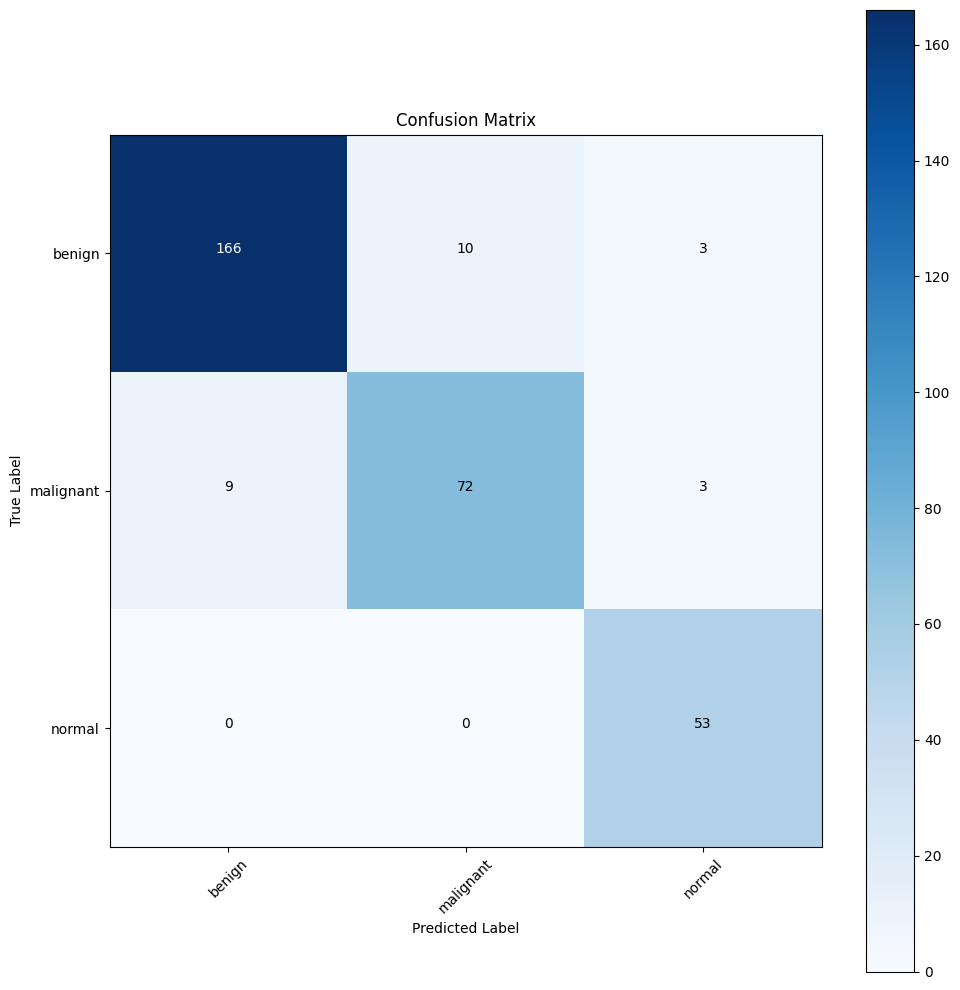

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [16]:
# Classification report
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

      benign       0.95      0.93      0.94       179
   malignant       0.88      0.86      0.87        84
      normal       0.90      1.00      0.95        53

    accuracy                           0.92       316
   macro avg       0.91      0.93      0.92       316
weighted avg       0.92      0.92      0.92       316



In [20]:
# Save the model using joblib
import joblib
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']